**Overview**  
This notebook describes folloiwing stages:
1. Creating functions to:
    - perform search for optimal algorithm parameters;
    - train model;
    - calculate the most important metrics;
    - plot ROC-AUC curve
2. Assess the results of following algorithms:
    - Logistic regression;
    - Random Forest;
    - Gradient Boosting as implemented in XGBoost;
    - Support Vector Machines;
    - K-Nearest Neighborrs
3. Creare dataframe with the main indiators of models' performance


In [256]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt\

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, cross_val_predict, cross_validate
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, roc_curve, recall_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

First, let's import datasets and y-target, created earlier:

In [258]:
with open('X_padel.pickle', 'rb') as input:
    X_padel = pickle.load(input)

In [260]:
with open('X_standard.pickle', 'rb') as input:
    X_standard = pickle.load(input)

In [262]:
with open('viscosity.pickle', 'rb') as input:
    target = pickle.load(input)
target = np.log10(target)

In [264]:
with open('X_standard.pickle', 'rb') as input:
    X_standard_pca = pickle.load(input)

In [266]:
with open('X_padel.pickle', 'rb') as input:
    X_padel_pca = pickle.load(input)

To facilitate automatic calculation of metrics and asiggning labels, we weill create dictionaries with imported descriptors datasets (standard datasets and datasetes with reduced dimensionality)

In [268]:
descriptors_dict = {'Standard':X_standard, 'Padel':X_padel}

In [269]:
descriptors_dict_pca = {'Standard':X_standard, 'Padel':X_padel}

In [343]:
scores = {'Descriptors':[], 'Estimator':[], 'Full or PCA':[], 'RMSE_CV':[], 'Stddev_RMSE_CV':[], 'R2_CV':[], 'MAE_CV':[],  'RMSE_test':[], 'MAE_test':[], 'R2_test':[] }

The function below performs multiple tasks:
1. First, it create matplotlib figure object and axes with two fields,
2. Then for each of two datasets in descriptors dictionary (standard and PCA), we:
    - Create a pipeline, made of MinMaxScaler and algorithm,
    - Split dataset into training and testing subsets;
    - Then we search for optimal parameters with functions from [hyperopt package](http://hyperopt.github.io/hyperopt/);
    - Then we extract the best model and train it with X_train and y_train;
    - Then we claculate different metrics (Accuracy, F1-Score, ROC_AUC score) and append it to the special dictionary with results, as well as some information abour descriptors sets and name of studied algorithm
    - Finally, we plot ROC-AUC curve 

In [341]:
def calculate_to_score(pipe, estimator_name, param_grid, descriptors_dict = descriptors_dict, target=target, type = 'Full'):
    fig, axes = plt.subplots(1, 2, figsize = (26,12))
    i = 0
    
    scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}
    for key, value in descriptors_dict.items():
        X_train, X_test, y_train, y_test = train_test_split(value, target, random_state = 0)
        def objective(params, X, target):
            #pipe = make_pipeline(MinMaxScaler(), estimator)
            pipe.set_params(**params)
            scores = cross_validate(pipe, X, target, cv = 10, scoring = scoring)
            rmse_cv = -scores['test_rmse']
            stddev_cv = rmse_cv.std()
            mae_cv = -scores['test_mae'].mean()
            r2_cv = scores['test_r2'].mean()
            
            return {'loss':rmse_cv.mean(), 'stddev':stddev_cv,  'status':STATUS_OK, 'Trained_model':pipe, 'R2_CV':r2_cv, 'MAE_CV':mae_cv}
            
        trials = Trials()
        best = fmin(partial(objective, X = X_train, target = y_train), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  50)
        print(best)
        best_model_and_properties = get_best_model_from_trials(trials)

        
        print('Loss is {}'.format(best_model_and_properties[2]))
        print('Standard deviation is {}'.format(best_model_and_properties[1]))
        best_estimator  = best_model_and_properties[0]
        
        scores['RMSE_CV'].append(best_model_and_properties[2])
        scores['Stddev_RMSE_CV'].append(best_model_and_properties[1])
        scores['R2_CV'].append(best_model_and_properties[3])
        scores['MAE_CV'].append(best_model_and_properties[4])
        best_estimator.fit(X_train, y_train)
        predictions = best_estimator.predict(X_test)

        
        scores['RMSE_test'].append(root_mean_squared_error(y_test, predictions))
        scores['MAE_test'].append(mean_absolute_error(y_test, predictions))
        scores['R2_test'].append(r2_score(y_test, predictions))
        scores['Full or PCA'].append(type)
        scores['Estimator'].append(estimator_name)
       
        axes[i].scatter(y_test, predictions)
        axes[i].set_xlim(np.min(y_test), np.max(y_test))
        axes[i].set_ylim(np.min(y_test), np.max(y_test))
        axes[i].plot([np.min(y_test),np.max(y_test)],[np.min(y_test),np.max(y_test)], 'k--')
        axes[i].set_title('Parity plot for {} descriptors'.format(key))
        axes[i].set_xlabel('Test values')
        axes[i].set_ylabel('Predicted values')
        scores['Descriptors'].append(key)
        i += 1
    plt.tight_layout()
    plt.savefig('Parity_plots_random/'+estimator_name+'_'+type+'.png')

Subfunction below is to retrieve best model from Trials object ans is used in main functions

In [345]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return (best_trial_obj['result']['Trained_model'], best_trial_obj['result']['stddev'], best_trial_obj['result']['loss'], 
            best_trial_obj['result']['R2_CV'],  best_trial_obj['result']['MAE_CV'])

Let's initialize scores dictionary and test function with Logistic Regression

In [347]:
pipe = Pipeline([('var_sel', VarianceThreshold(threshold=0.1)), ('scaler', StandardScaler()), 
                 ('lasso',Lasso(max_iter=15000))])

In [349]:
param_grid = {'var_sel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4), 
             'lasso__alpha':hp.loguniform(label = 'alpha', low = -2, high  = 2)}

100%|██████████| 50/50 [00:49<00:00,  1.00trial/s, best loss: 1.504065270547115] 
{'alpha': 0.14580691853658764, 'threshold': 0.18417211247679838}
Loss is 1.504065270547115
Standard deviation is 0.1414868189524516
100%|██████████| 50/50 [00:49<00:00,  1.01trial/s, best loss: 1.4941803555825506]
{'alpha': 0.13812810741569698, 'threshold': 0.3059940494875522}
Loss is 1.4941803555825506
Standard deviation is 0.14636207706663962


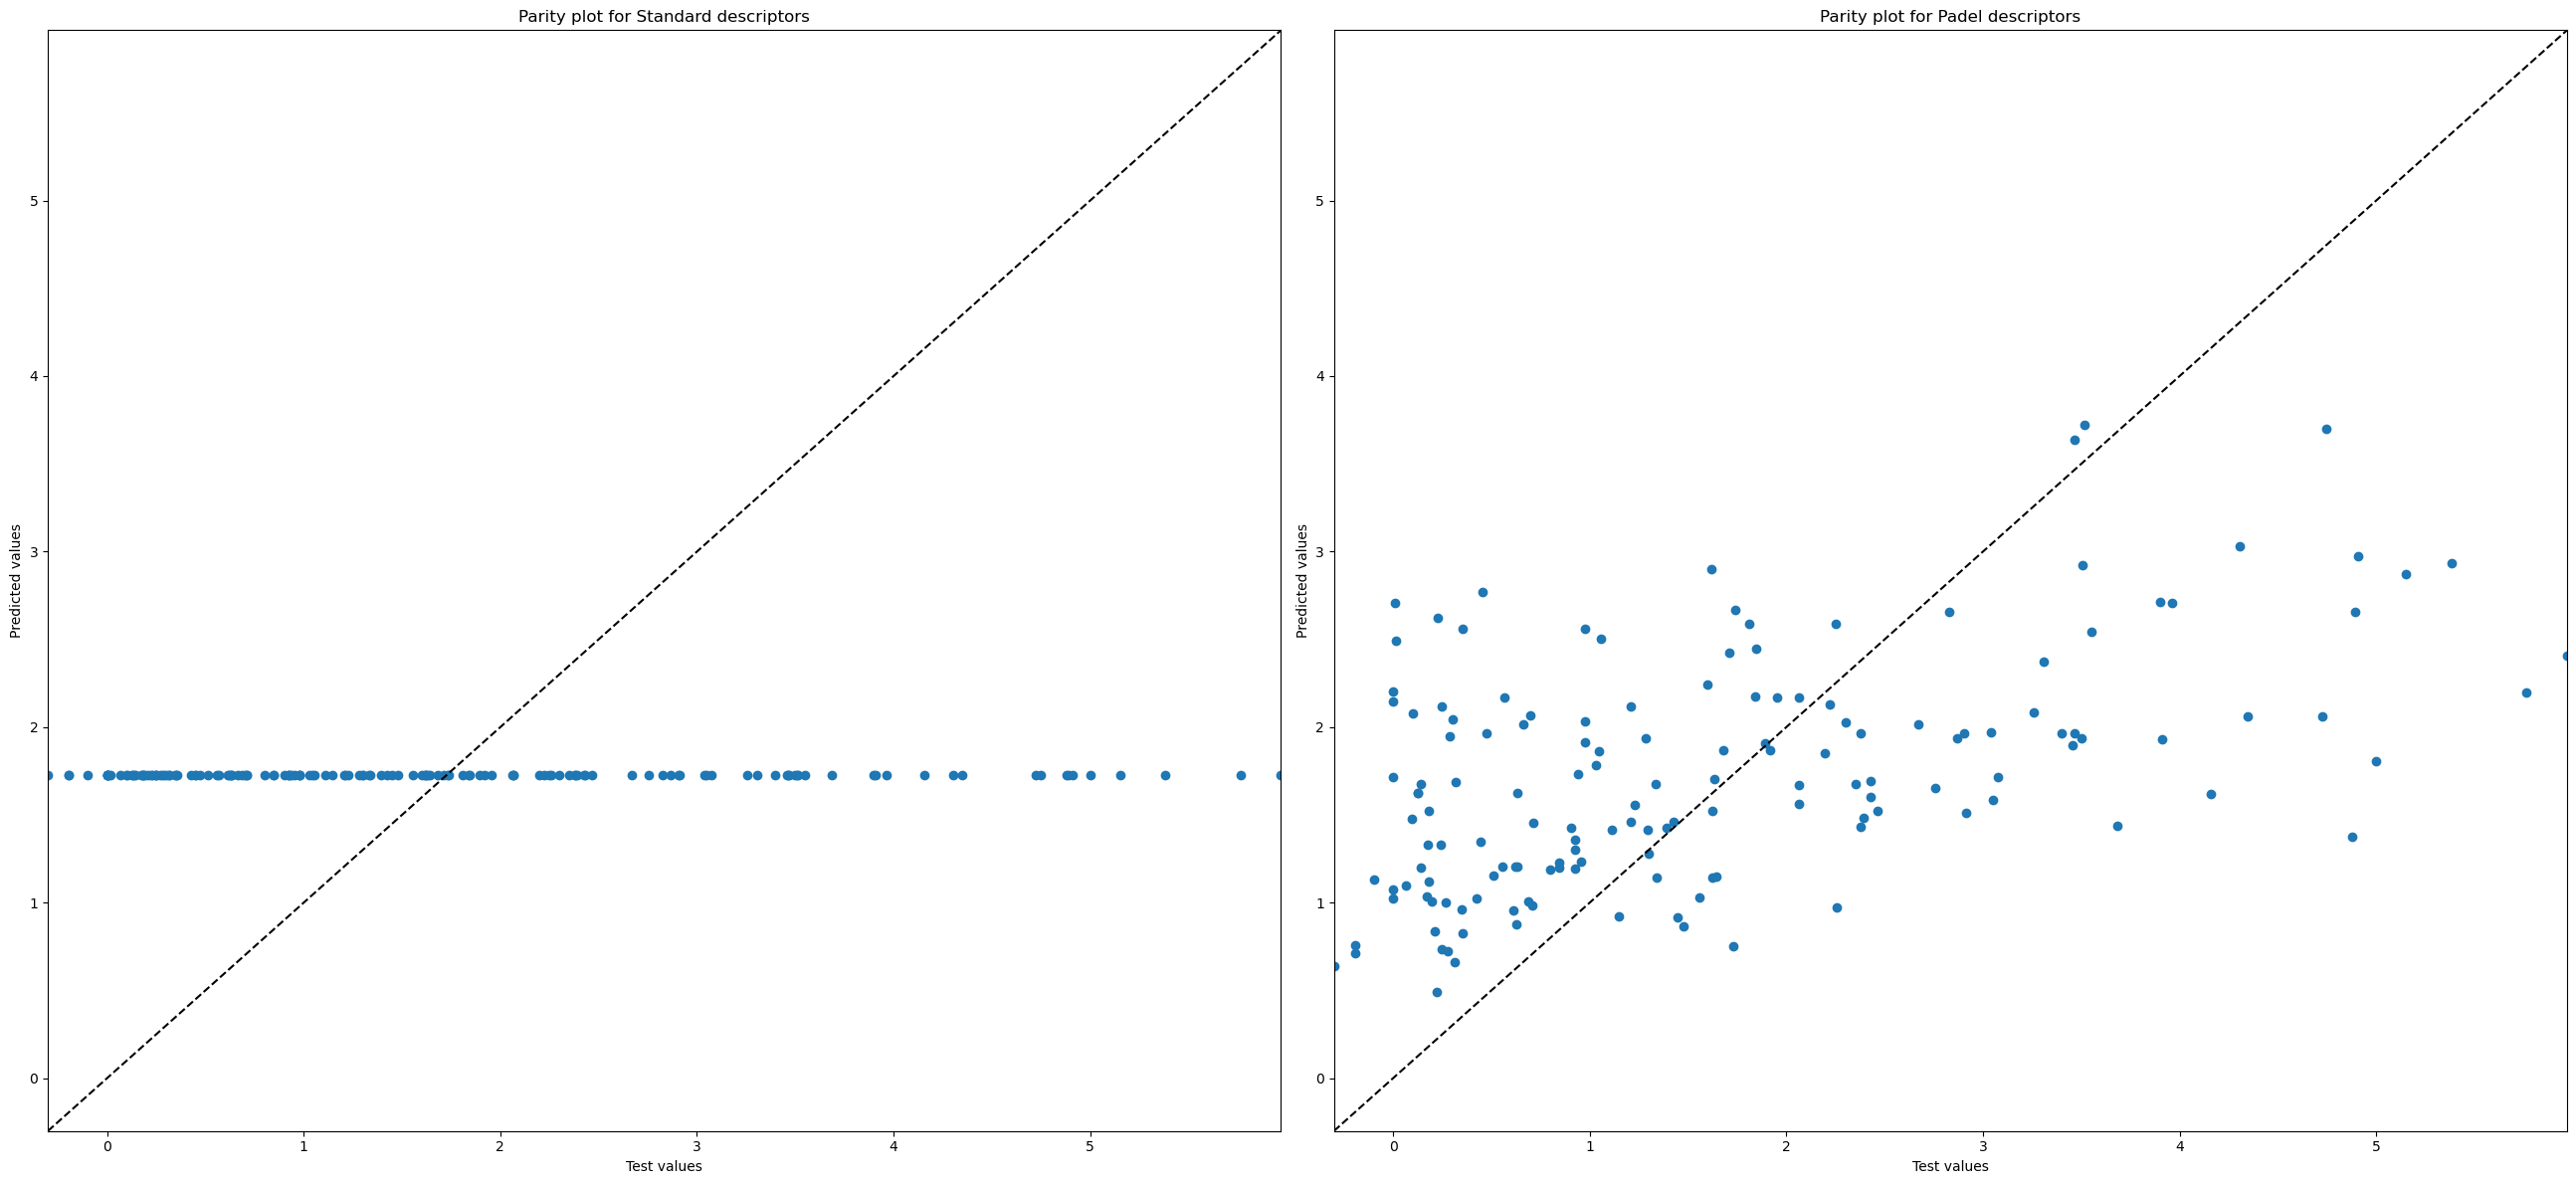

In [351]:
calculate_to_score(pipe, estimator_name='Lasso regression', 
                   param_grid = param_grid)

100%|██████████| 50/50 [00:51<00:00,  1.04s/trial, best loss: 1.5090995980764175]
{'alpha': 0.1367536670406521, 'threshold': 0.11226355418860759}
Loss is 1.5090995980764175
Standard deviation is 0.14638060643480108
100%|██████████| 50/50 [00:59<00:00,  1.20s/trial, best loss: 1.4818808656698887]
{'alpha': 0.13604401942155434, 'threshold': 0.08999195249733863}
Loss is 1.4818808656698887
Standard deviation is 0.14545826001000345


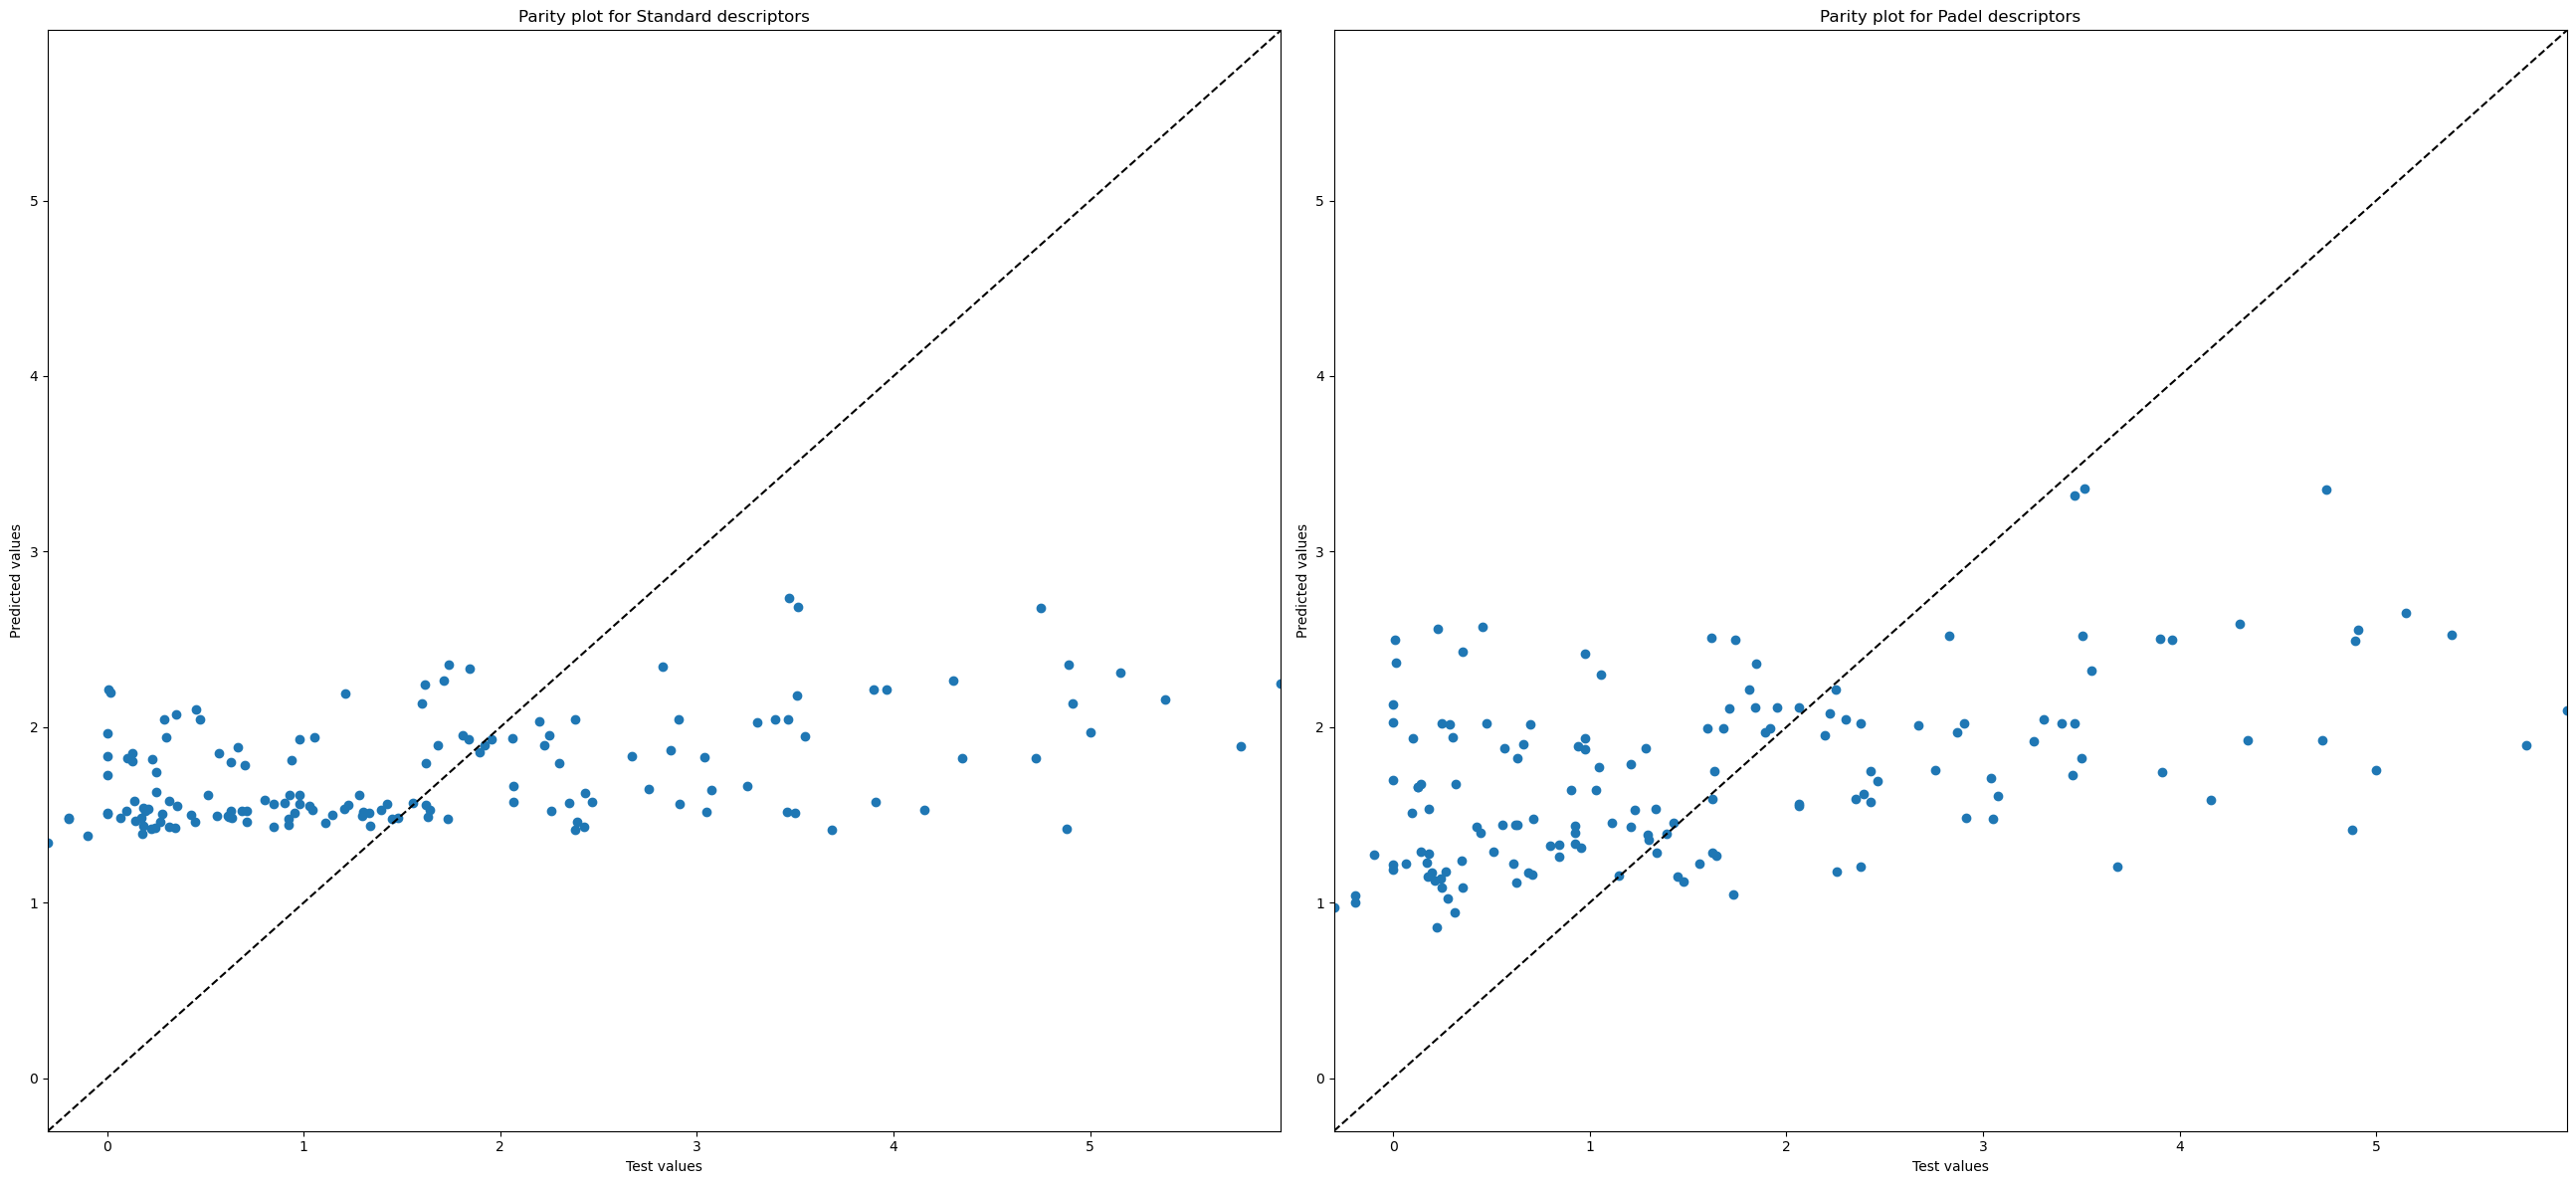

In [352]:
calculate_to_score(pipe, estimator_name='Lasso Regression', 
                   param_grid = param_grid,
                  descriptors_dict=descriptors_dict_pca, type = 'PCA')

Let's continue with other models. The first one will be
**Random Forest Classification**

In [357]:
pipe = Pipeline([('varsel', VarianceThreshold()),('randomforest', RandomForestRegressor(n_jobs = -1))])

In [359]:
space={'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
    'randomforest__max_depth':hp.randint('max_depth',1,25),  'randomforest__max_features':hp.choice('max_features', [None, 'sqrt', 'log2']),
       'randomforest__min_samples_split':hp.randint('min_samples_split', 2, 8),
       'randomforest__min_samples_leaf': hp.randint('min_samples_leaf', 2, 10),
      'randomforest__n_estimators':hp.randint('n_estimators',10, 150),
      'randomforest__criterion': hp.choice('criterion', ["squared_error", "absolute_error", "friedman_mse"])}

100%|██████████| 50/50 [13:36<00:00, 16.33s/trial, best loss: 1.1738930771353098]
{'criterion': 0, 'max_depth': 23, 'max_features': 0, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 115, 'threshold': 0.22783244992871393}
Loss is 1.1738930771353098
Standard deviation is 0.1436498773067518
100%|██████████| 50/50 [15:27<00:00, 18.56s/trial, best loss: 1.0536552774150998]
{'criterion': 2, 'max_depth': 13, 'max_features': 0, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 64, 'threshold': 0.1477989441650962}
Loss is 1.0536552774150998
Standard deviation is 0.16439407311313814


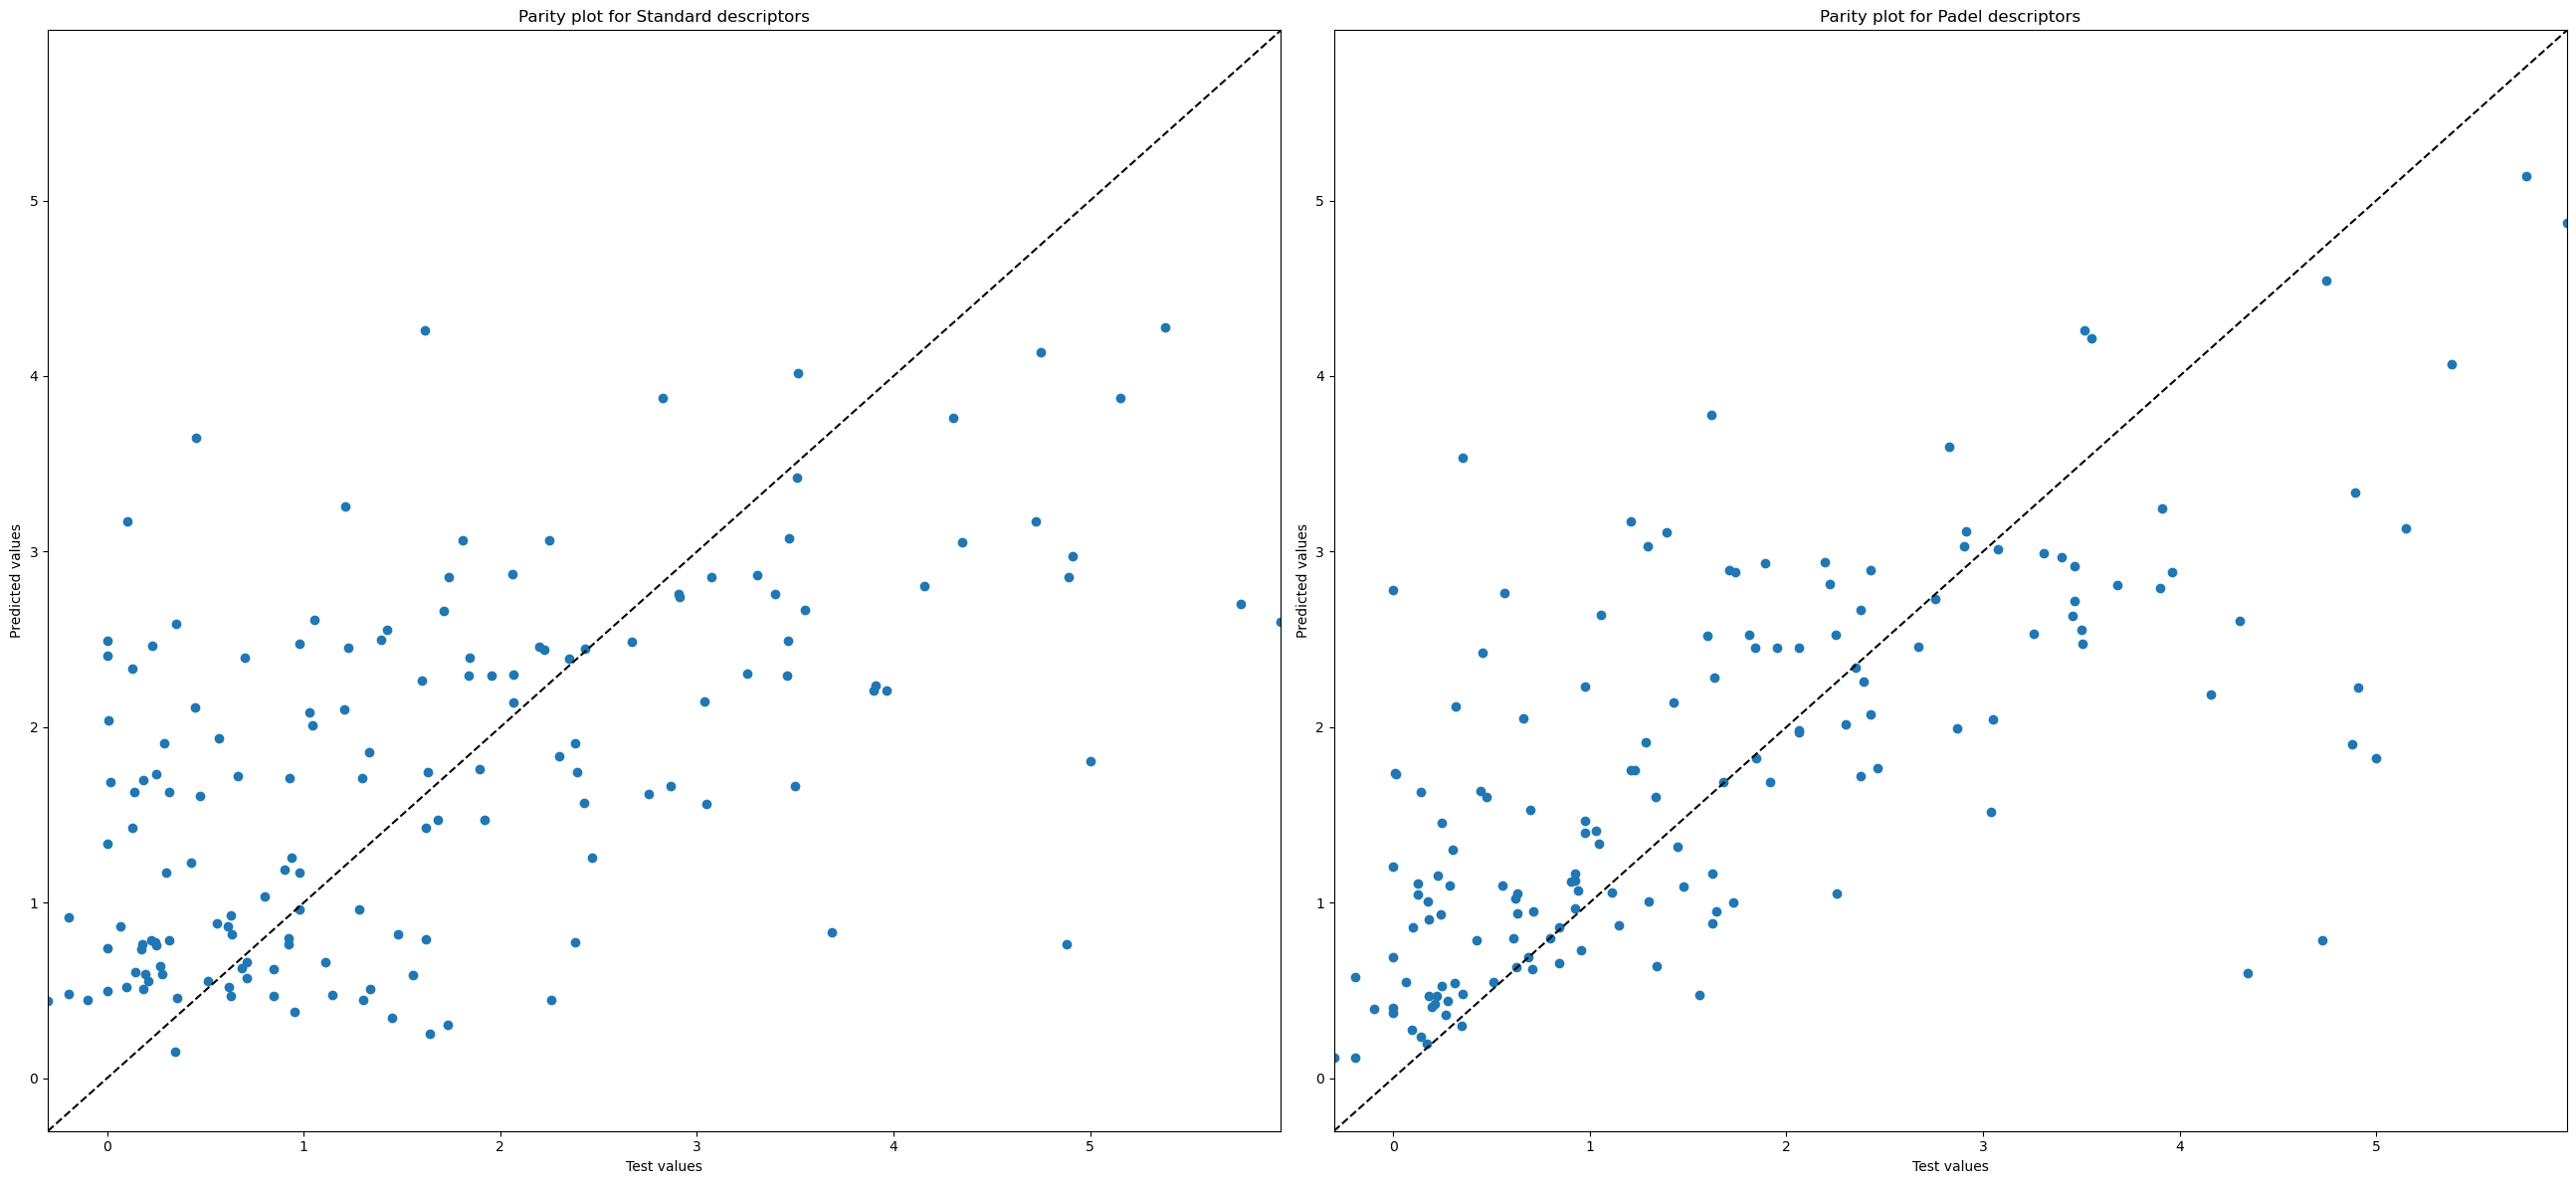

In [361]:
calculate_to_score(pipe, estimator_name = 'Random Forest', param_grid =  space,
                   descriptors_dict=descriptors_dict,
                   target=target,type = 'Full')
               

100%|██████████| 50/50 [09:47<00:00, 11.75s/trial, best loss: 1.165981943637422] 
{'criterion': 2, 'max_depth': 15, 'max_features': 0, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 38, 'threshold': 0.24672455729198706}
Loss is 1.165981943637422
Standard deviation is 0.1605657988990867
100%|██████████| 50/50 [10:59<00:00, 13.19s/trial, best loss: 1.1044173498794292]
{'criterion': 0, 'max_depth': 13, 'max_features': 0, 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 50, 'threshold': 0.27661358599354596}
Loss is 1.1044173498794292
Standard deviation is 0.1616610070929755


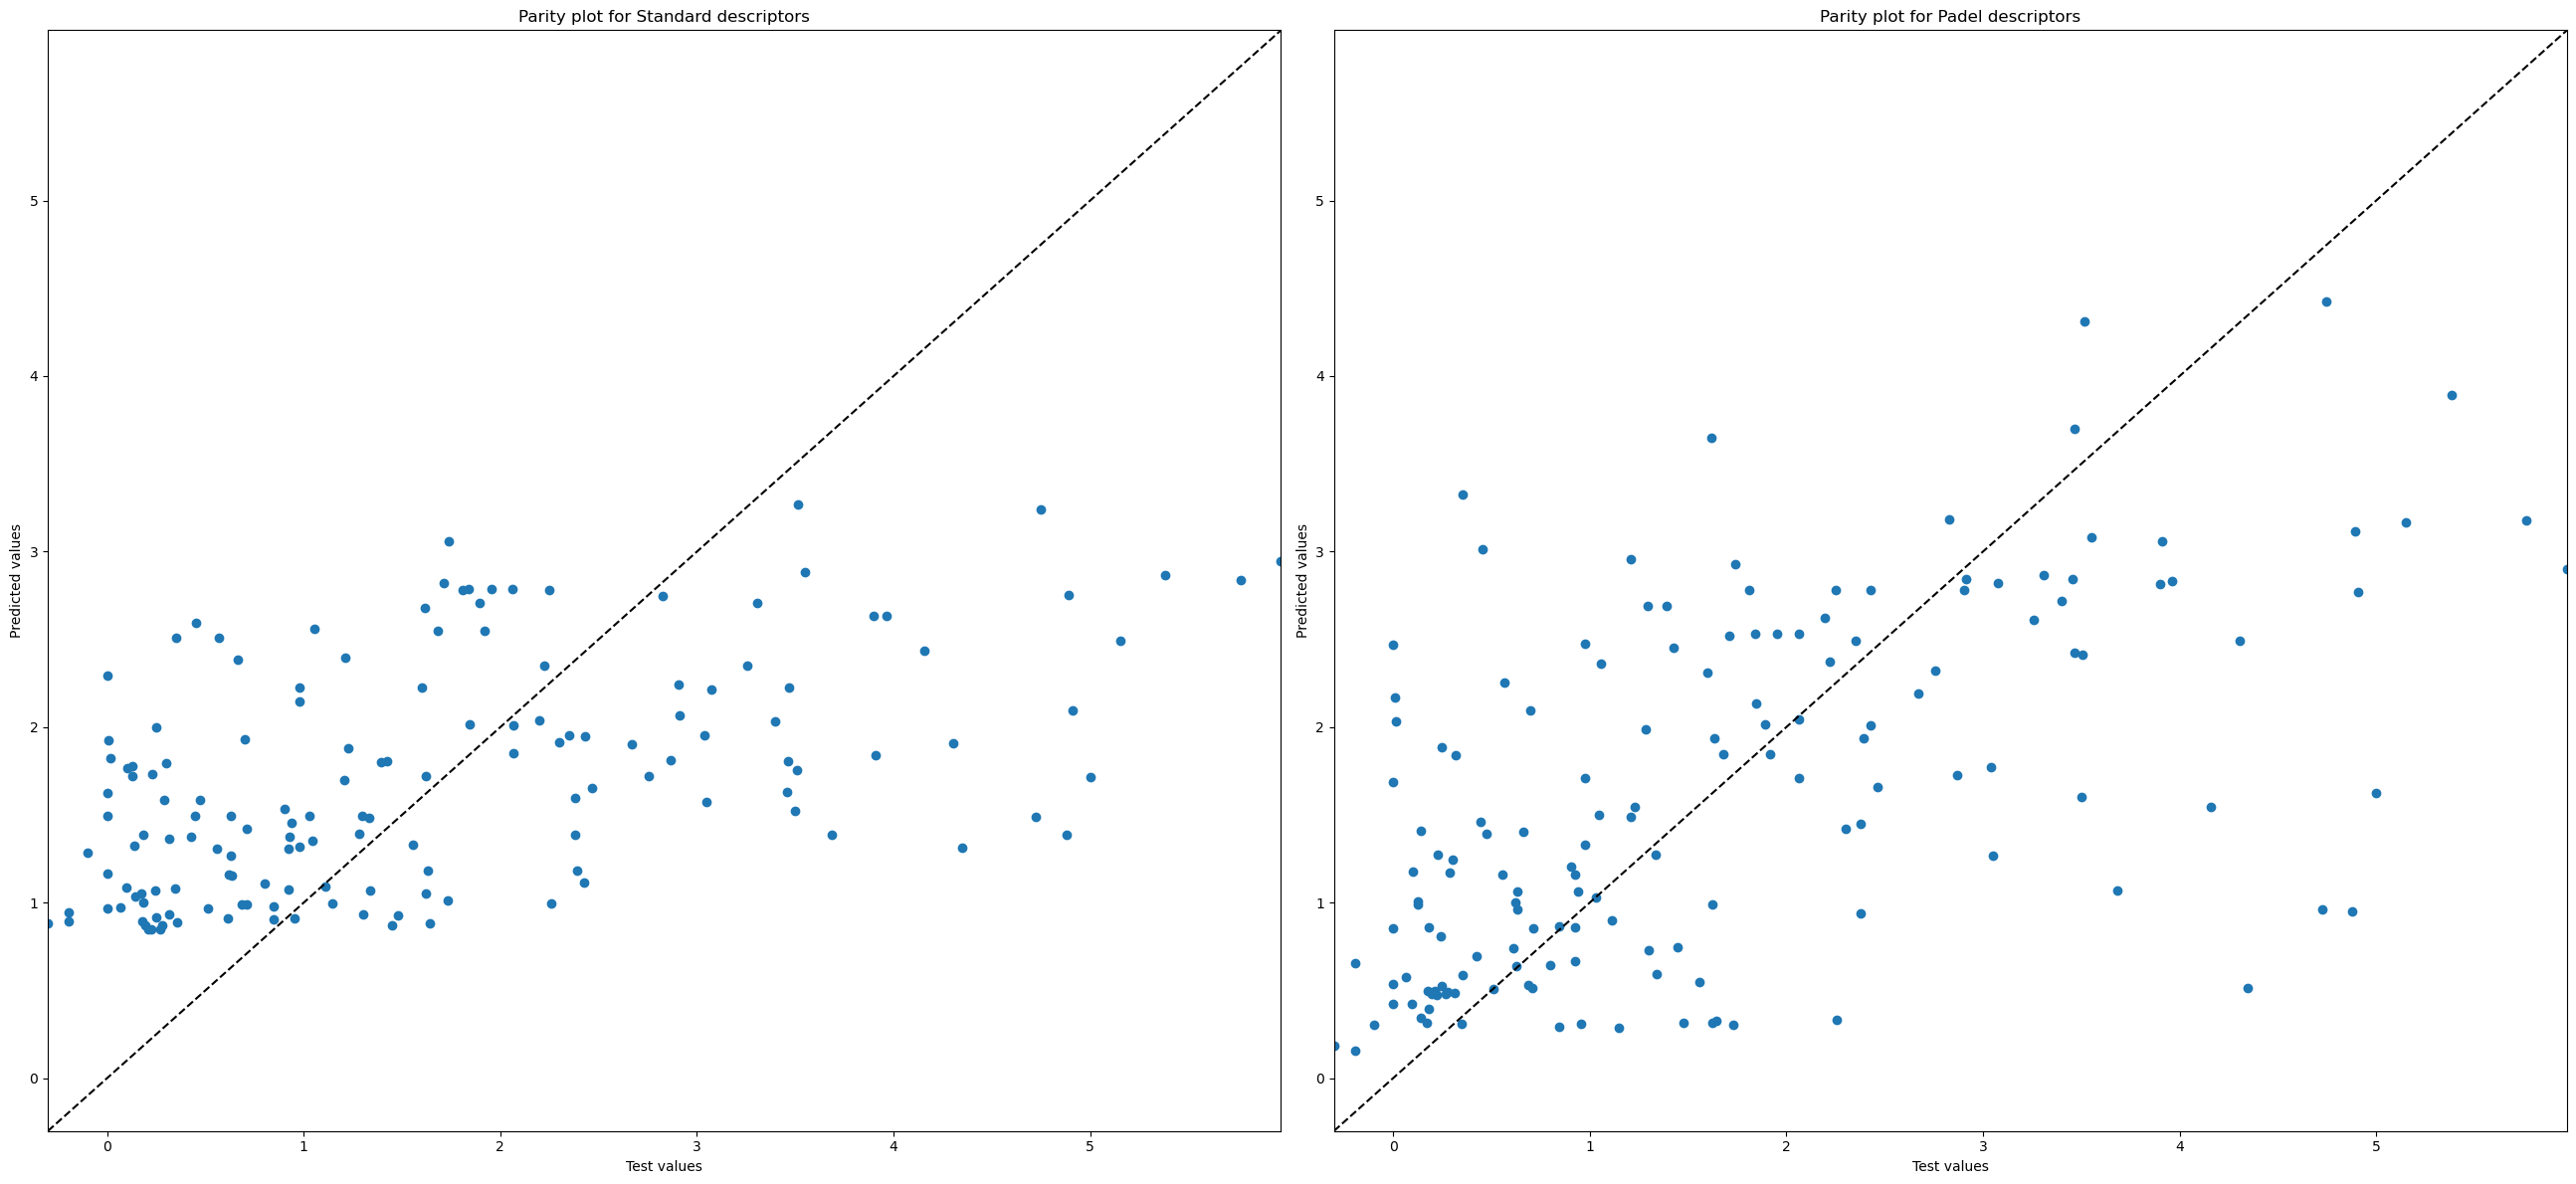

In [362]:
calculate_to_score(pipe, estimator_name = 'Random Forest', param_grid =  space,
                   descriptors_dict=descriptors_dict_pca,
                   target=target,                   type = 'PCA')


**SVM**

In [363]:
pipe = Pipeline([('varsel',VarianceThreshold()),
                 ('scaler',StandardScaler()),
                 ('model_sel',SelectFromModel(Lasso(max_iter=10000))),
                 ('svc', SVR())])

In [364]:
pipe = Pipeline([('varsel',VarianceThreshold()),
                 ('scaler',StandardScaler()),
                 ('svc', SVR())])

In [365]:
space = {'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
         #'model_sel__estimator__alpha':hp.loguniform(label = 'alpha', low = -1, high =2),
    'svc__C':hp.loguniform('C', -3*np.log(10), 2*np.log(10)),
         'svc__kernel':hp.choice('kernel', ['rbf','poly','linear', 'sigmoid']),
         'svc__degree':hp.choice('degree', [2,3]),
         'svc__gamma':hp.choice('gamma', ['scale', 'auto']),
         'svc__coef0':hp.loguniform('coef0', -3*np.log(10), 0*np.log(10))}

100%|██████████| 50/50 [03:08<00:00,  3.77s/trial, best loss: 1.5247042567304117]
{'C': 2.3666431035711035, 'coef0': 0.5272195487522086, 'degree': 0, 'gamma': 1, 'kernel': 0, 'threshold': 0.36965560707507017}
Loss is 1.5247042567304117
Standard deviation is 0.1606280445767886
100%|██████████| 50/50 [01:57<00:00,  2.36s/trial, best loss: 1.4474766469587306]
{'C': 92.66496444683818, 'coef0': 0.05294669187975832, 'degree': 0, 'gamma': 1, 'kernel': 0, 'threshold': 0.39399115277941604}
Loss is 1.4474766469587306
Standard deviation is 0.28047132716241835


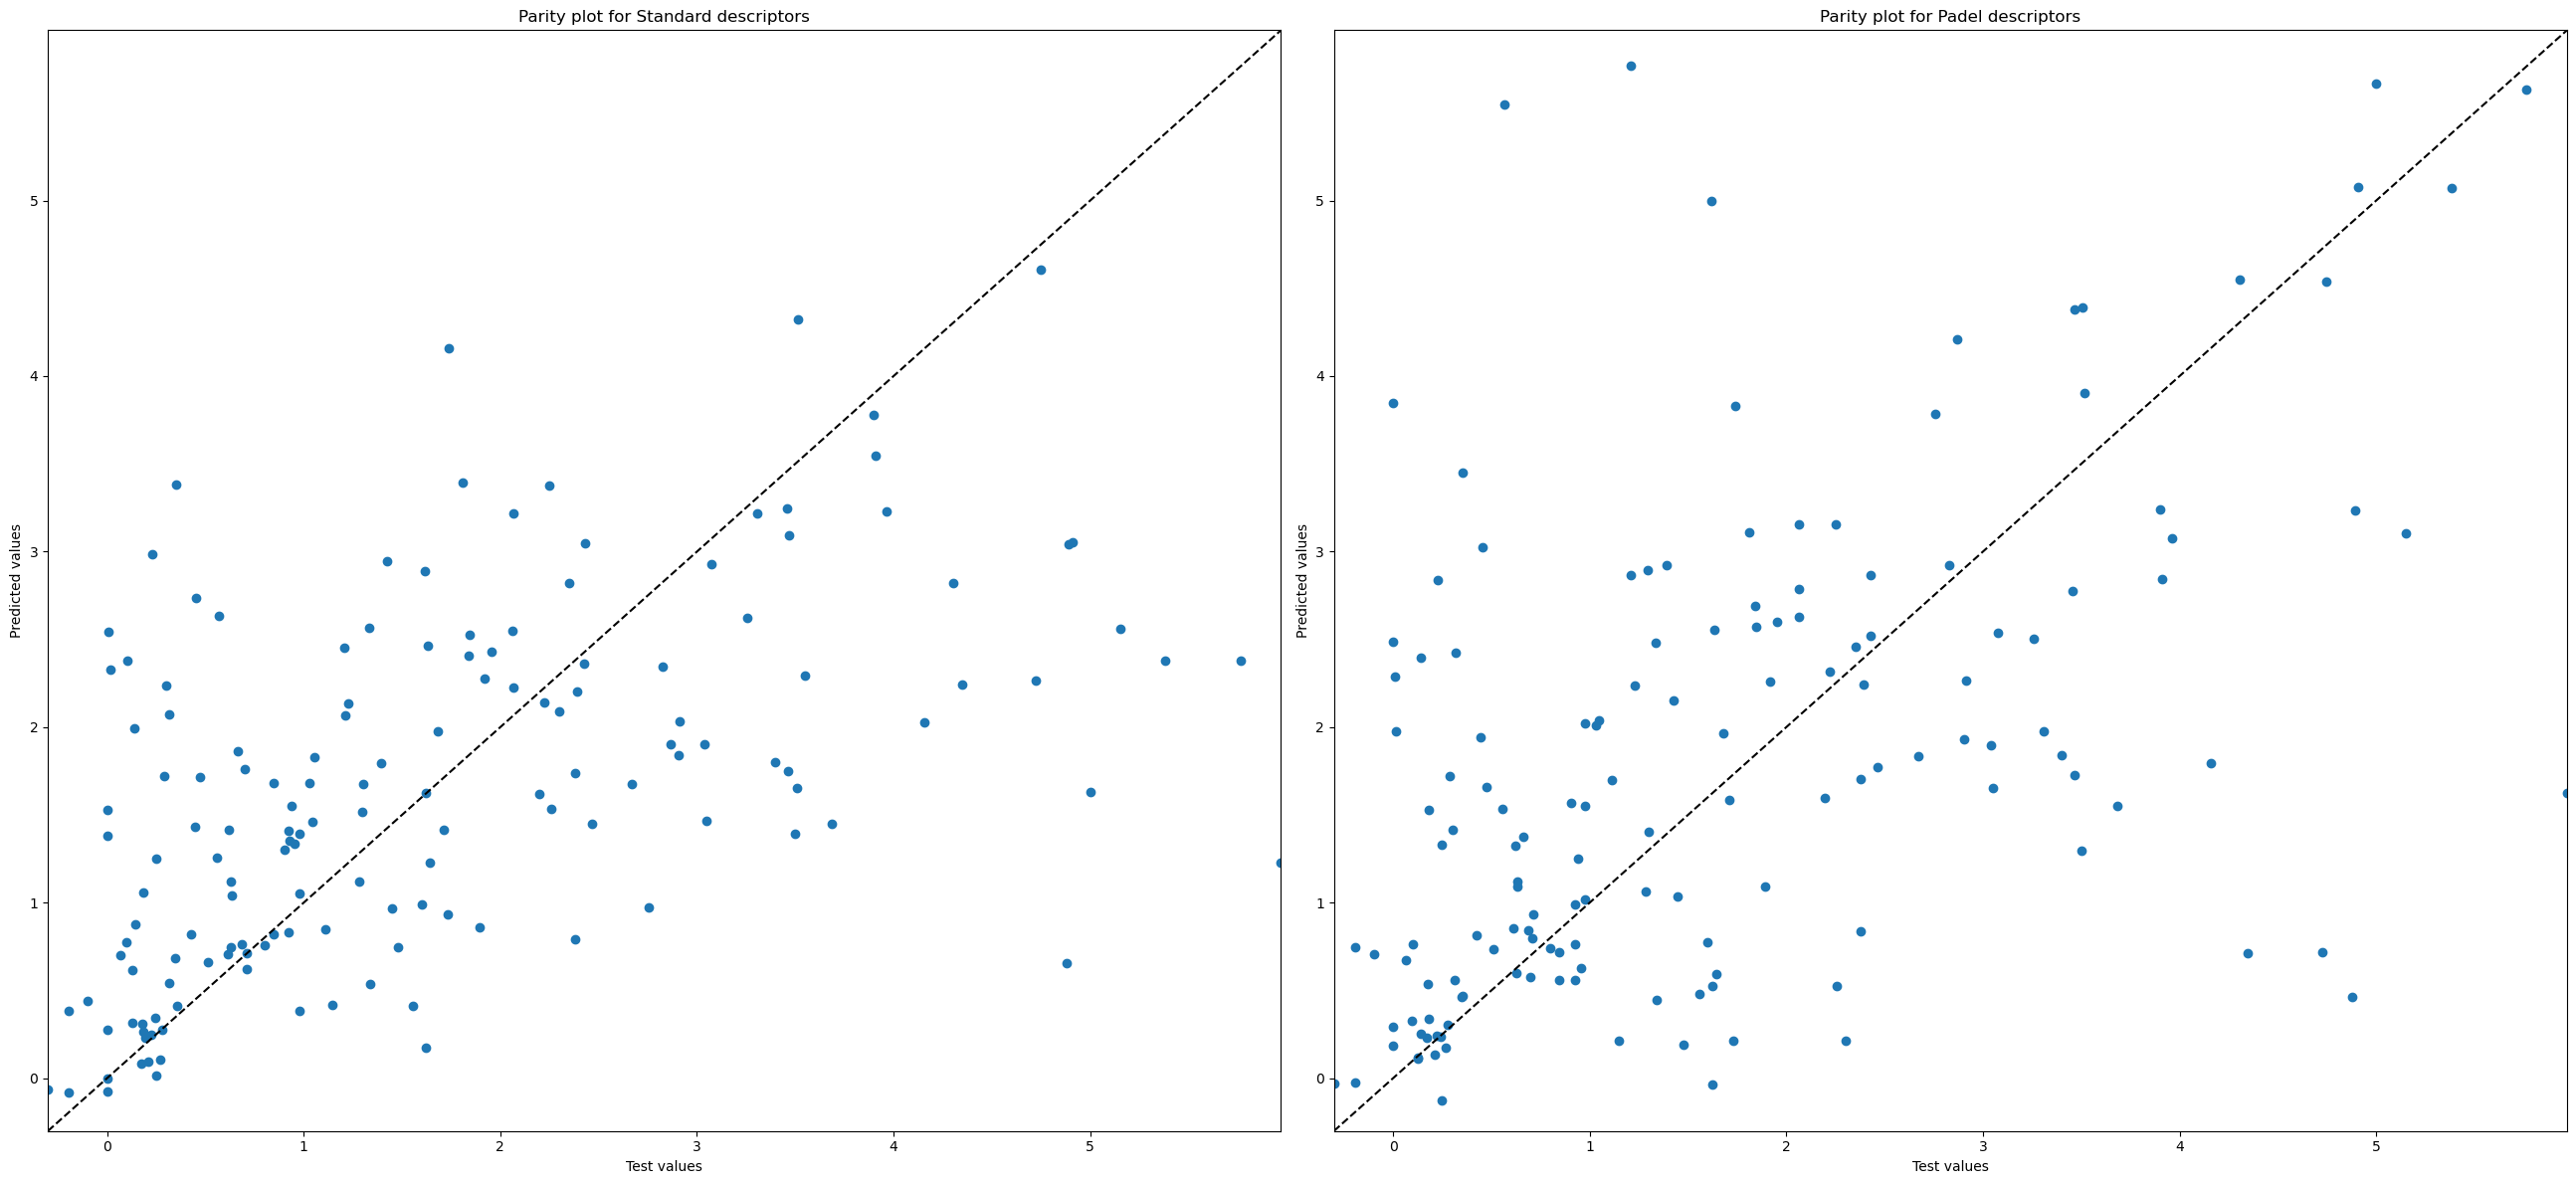

In [366]:
calculate_to_score(pipe, estimator_name = 'SVC', param_grid = space, descriptors_dict=descriptors_dict, target = target, type = 'Full')
                                                                


100%|██████████| 50/50 [01:28<00:00,  1.76s/trial, best loss: 1.5232220168118233]
{'C': 2.2794990611404855, 'coef0': 0.12948034219318316, 'degree': 0, 'gamma': 1, 'kernel': 0, 'threshold': 0.3314300214028729}
Loss is 1.5232220168118233
Standard deviation is 0.15810143335845825
100%|██████████| 50/50 [01:44<00:00,  2.08s/trial, best loss: 1.4407494969981192]
{'C': 85.68402871343132, 'coef0': 0.5477459392887297, 'degree': 1, 'gamma': 1, 'kernel': 1, 'threshold': 0.3441427098291167}
Loss is 1.4407494969981192
Standard deviation is 0.26671887131648236


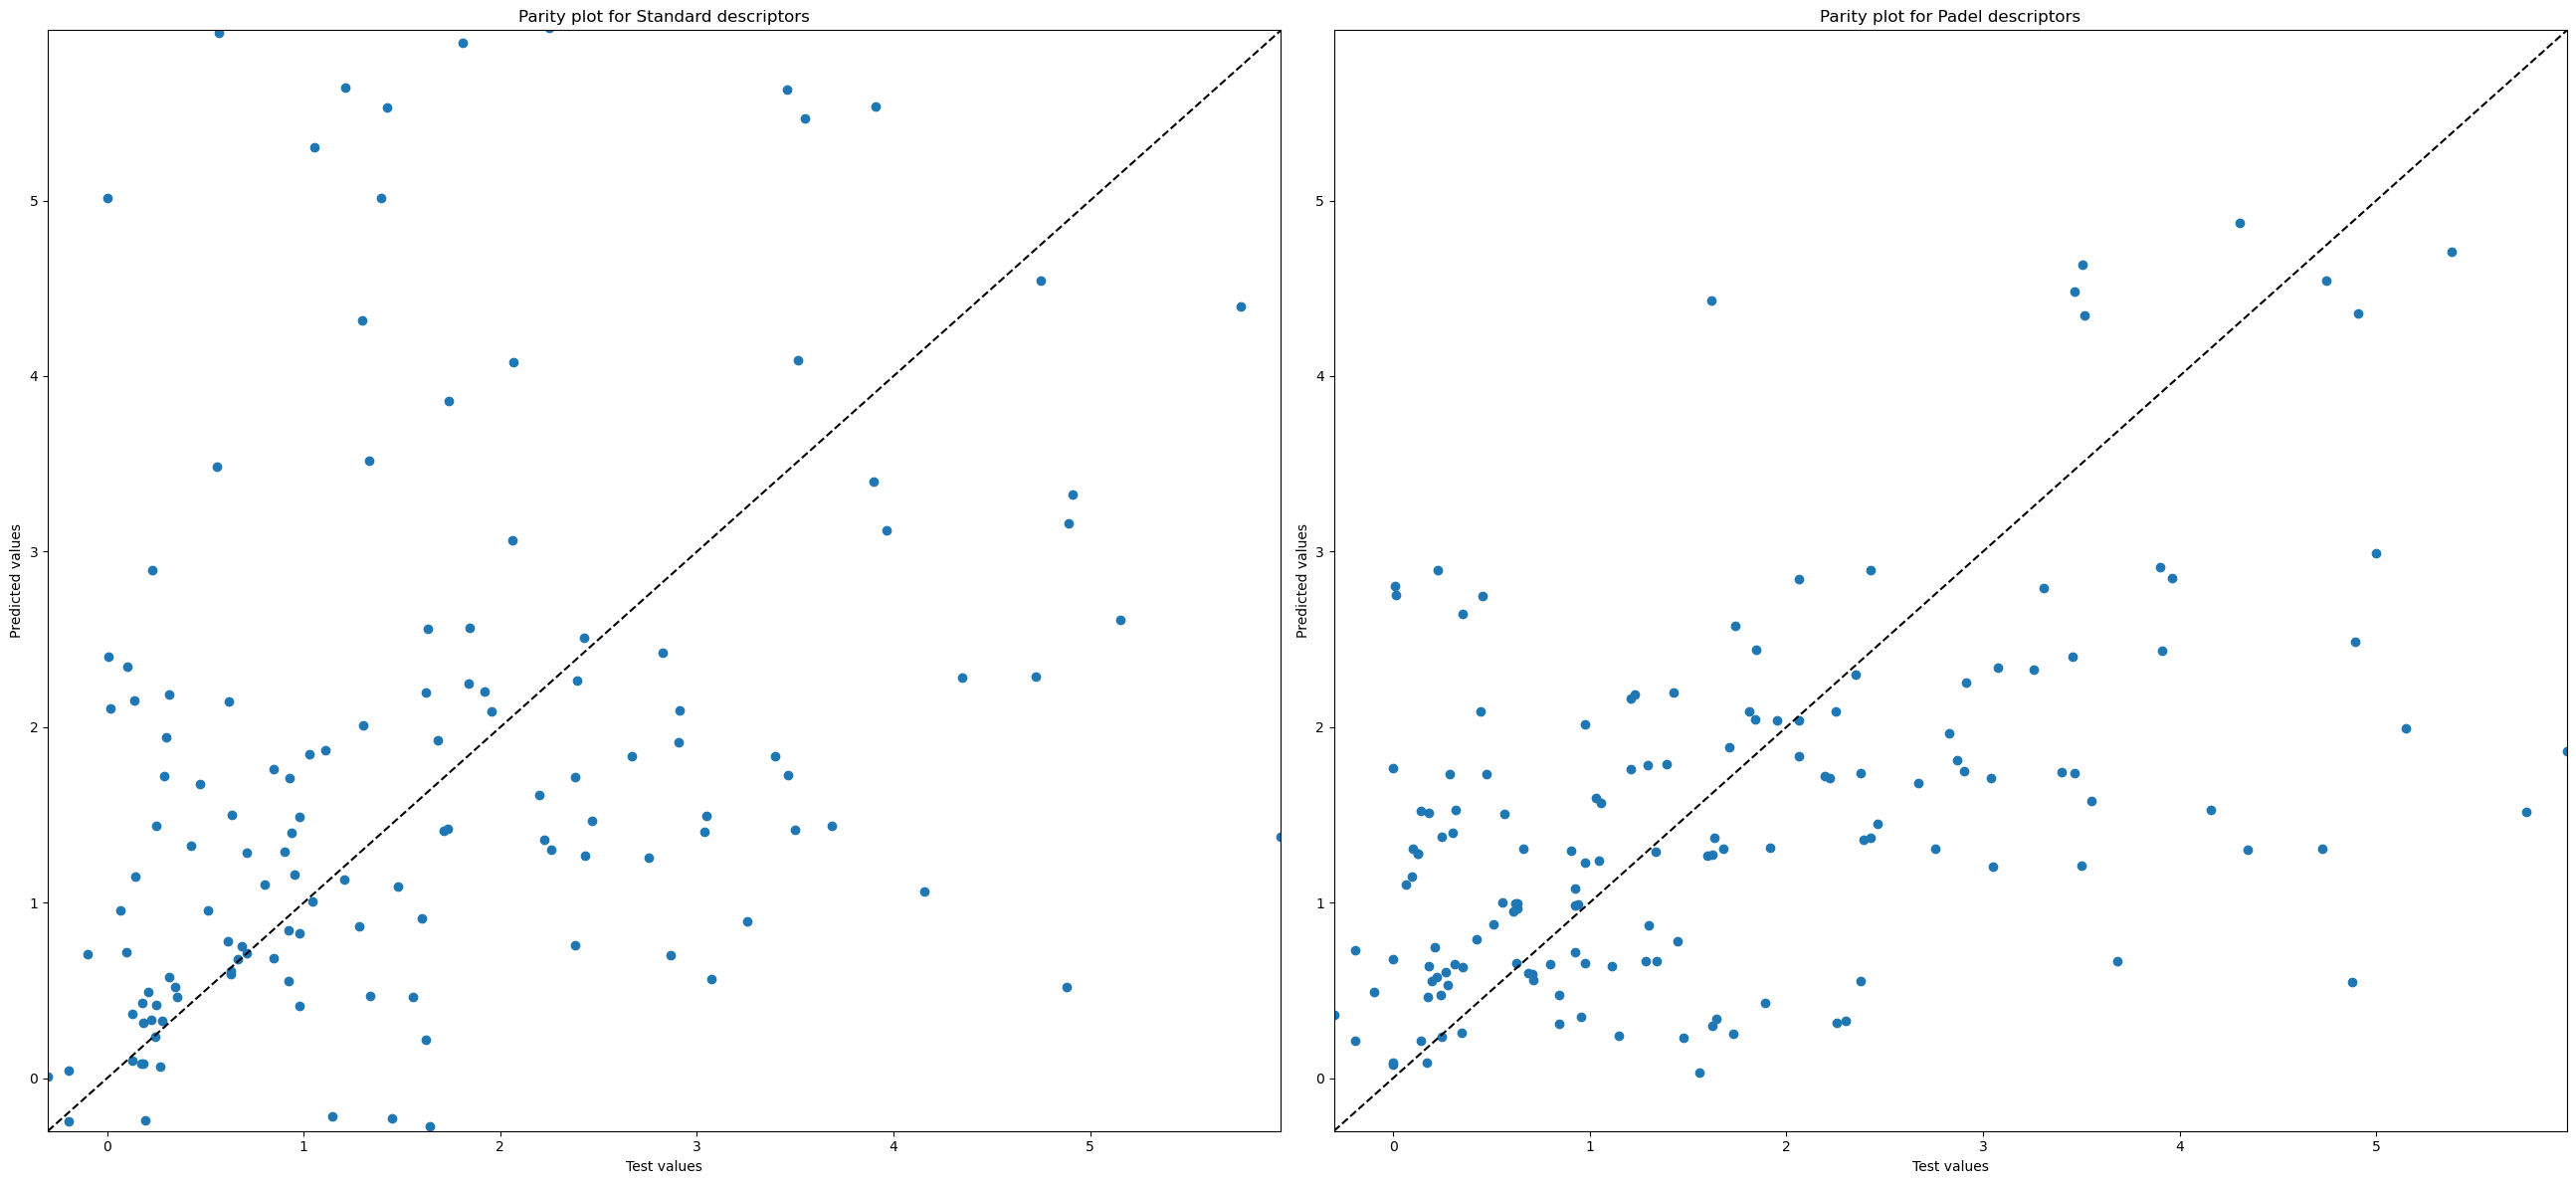

In [367]:
calculate_to_score(pipe, estimator_name = 'SVC', param_grid = space, descriptors_dict=descriptors_dict_pca, target = target, type = 'PCA')


**KNearestneighbors**

In [368]:
pipe = Pipeline([('varsel',VarianceThreshold()),
                 ('scaler',StandardScaler()),
                 ('kneighborsregressor', KNeighborsRegressor())])

In [369]:
space = {'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
    'kneighborsregressor__n_neighbors':hp.randint('n_neighbors',1, 10),
         'kneighborsregressor__weights':hp.choice('weights', ['uniform', 'distance']),
         'kneighborsregressor__metric':hp.choice('metric', ['minkowski', 'chebyshev', 'cosine', 'euclidean'])}


100%|██████████| 50/50 [00:48<00:00,  1.02trial/s, best loss: 1.4714848535708802]
{'metric': 0, 'n_neighbors': 4, 'threshold': 0.16596576814950553, 'weights': 0}
Loss is 1.4714848535708802
Standard deviation is 0.16914113335345834
100%|██████████| 50/50 [00:50<00:00,  1.02s/trial, best loss: 1.3869570689866153]
{'metric': 0, 'n_neighbors': 9, 'threshold': 0.3090147458099175, 'weights': 1}
Loss is 1.3869570689866153
Standard deviation is 0.18583133928261616


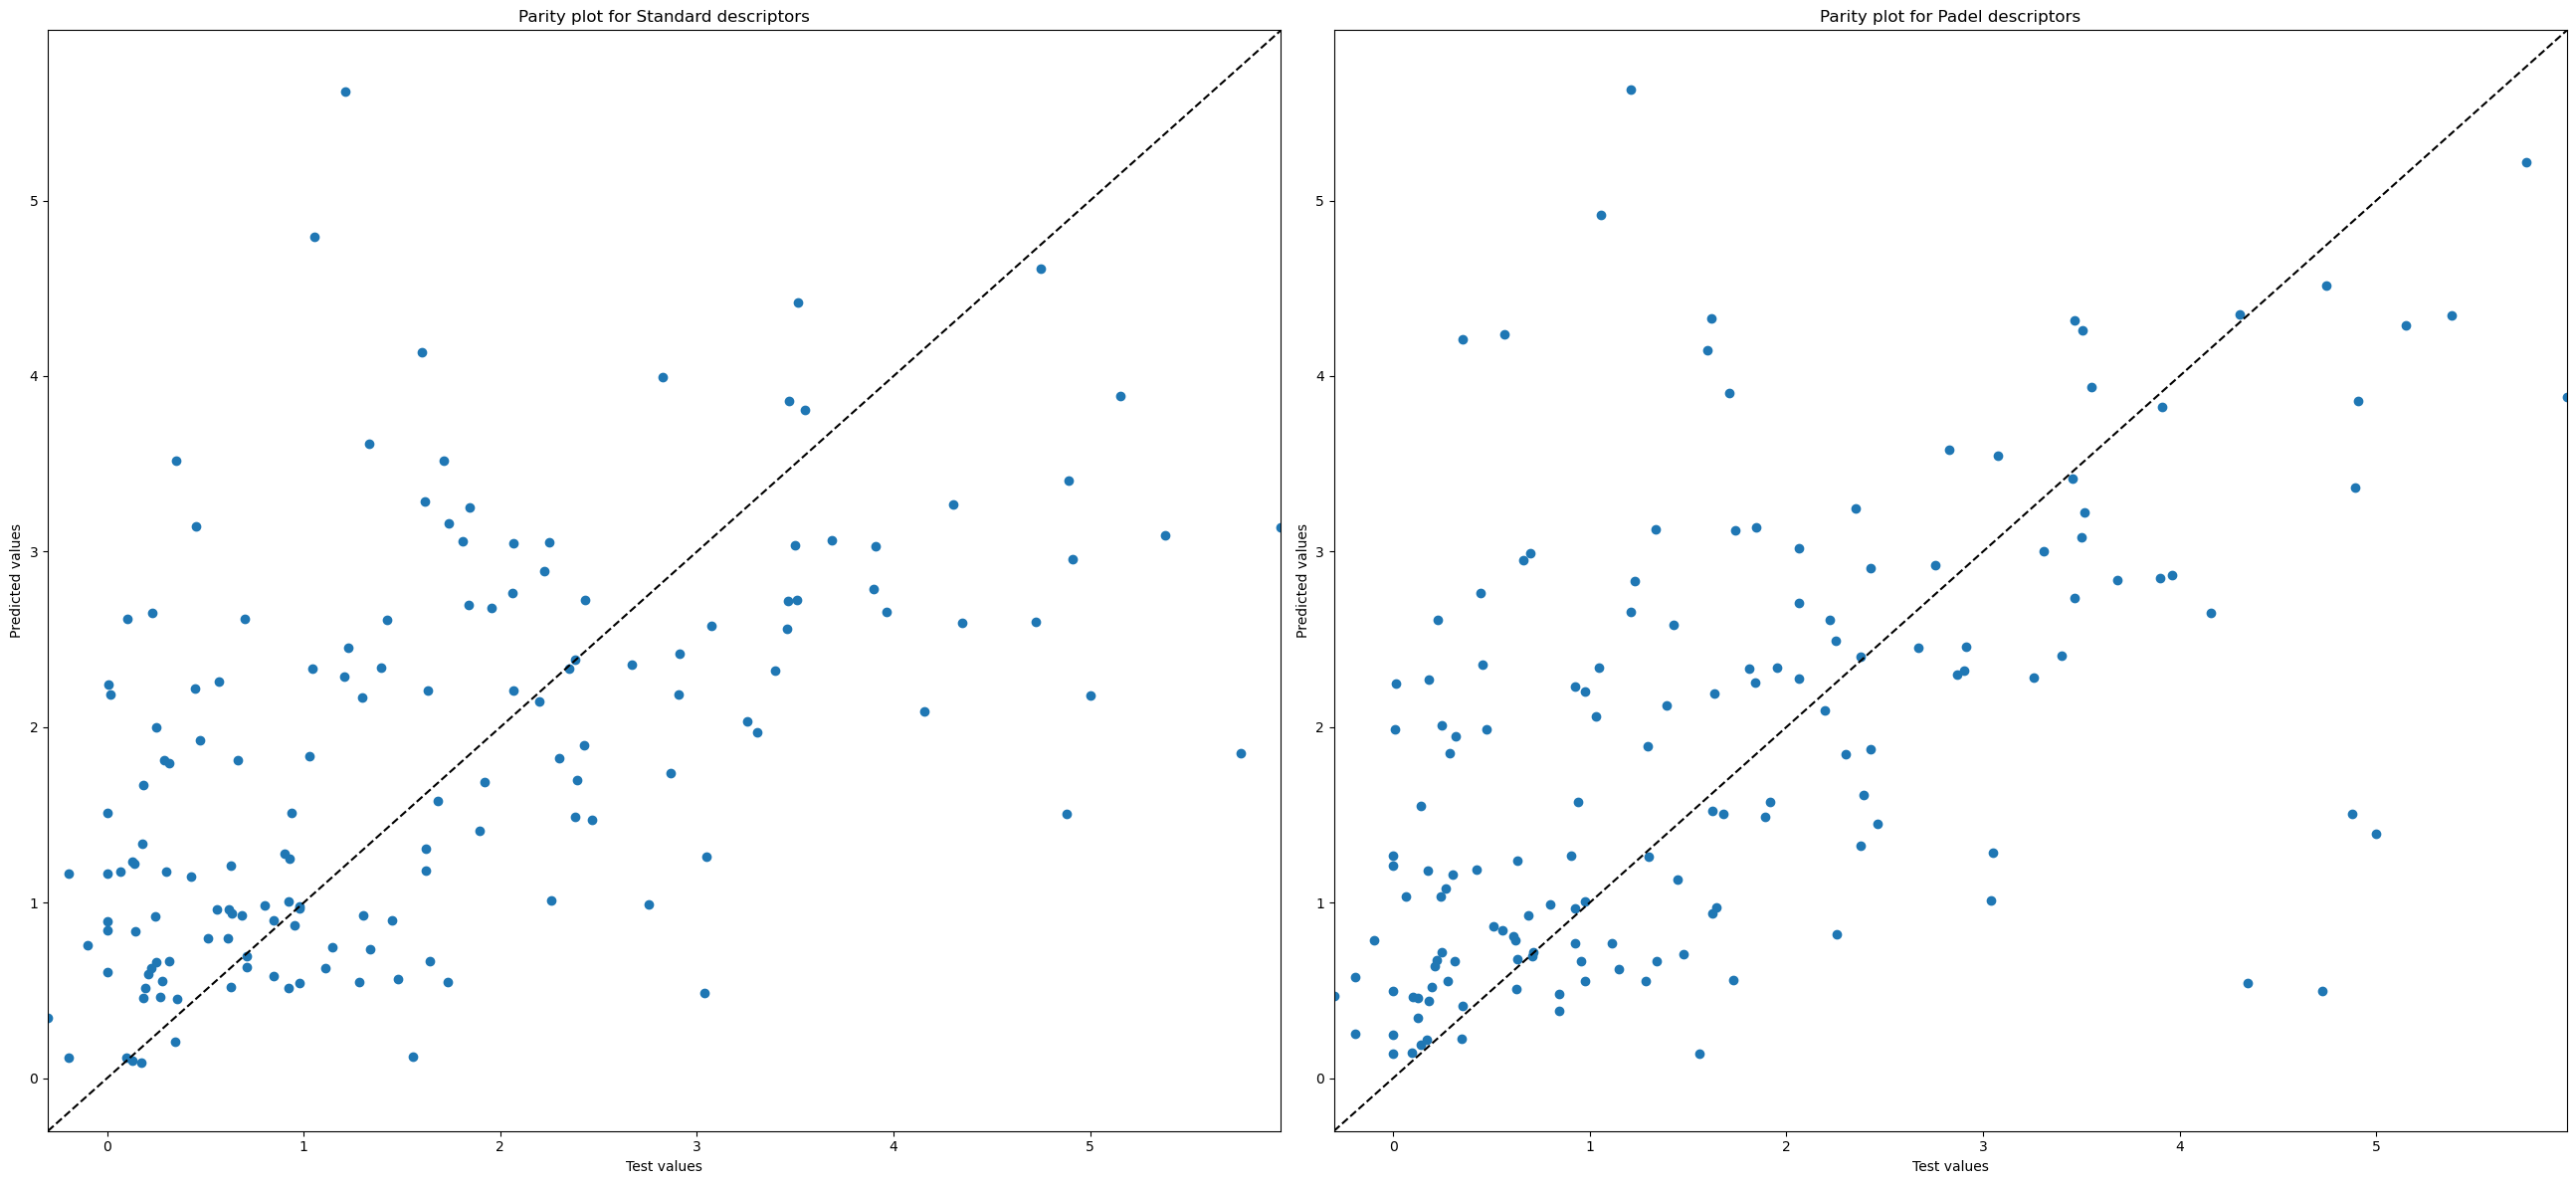

In [370]:
calculate_to_score(pipe, estimator_name='KMeans', param_grid=space, 
                   descriptors_dict=descriptors_dict, target=target, type = 'Full')

100%|██████████| 50/50 [00:49<00:00,  1.00trial/s, best loss: 1.4647360573965214]
{'metric': 3, 'n_neighbors': 4, 'threshold': 0.1848085652379896, 'weights': 0}
Loss is 1.4647360573965214
Standard deviation is 0.1618580609662175
100%|██████████| 50/50 [00:50<00:00,  1.00s/trial, best loss: 1.3850908473152814]
{'metric': 2, 'n_neighbors': 6, 'threshold': 0.31921329488464506, 'weights': 1}
Loss is 1.3850908473152814
Standard deviation is 0.229117541038854


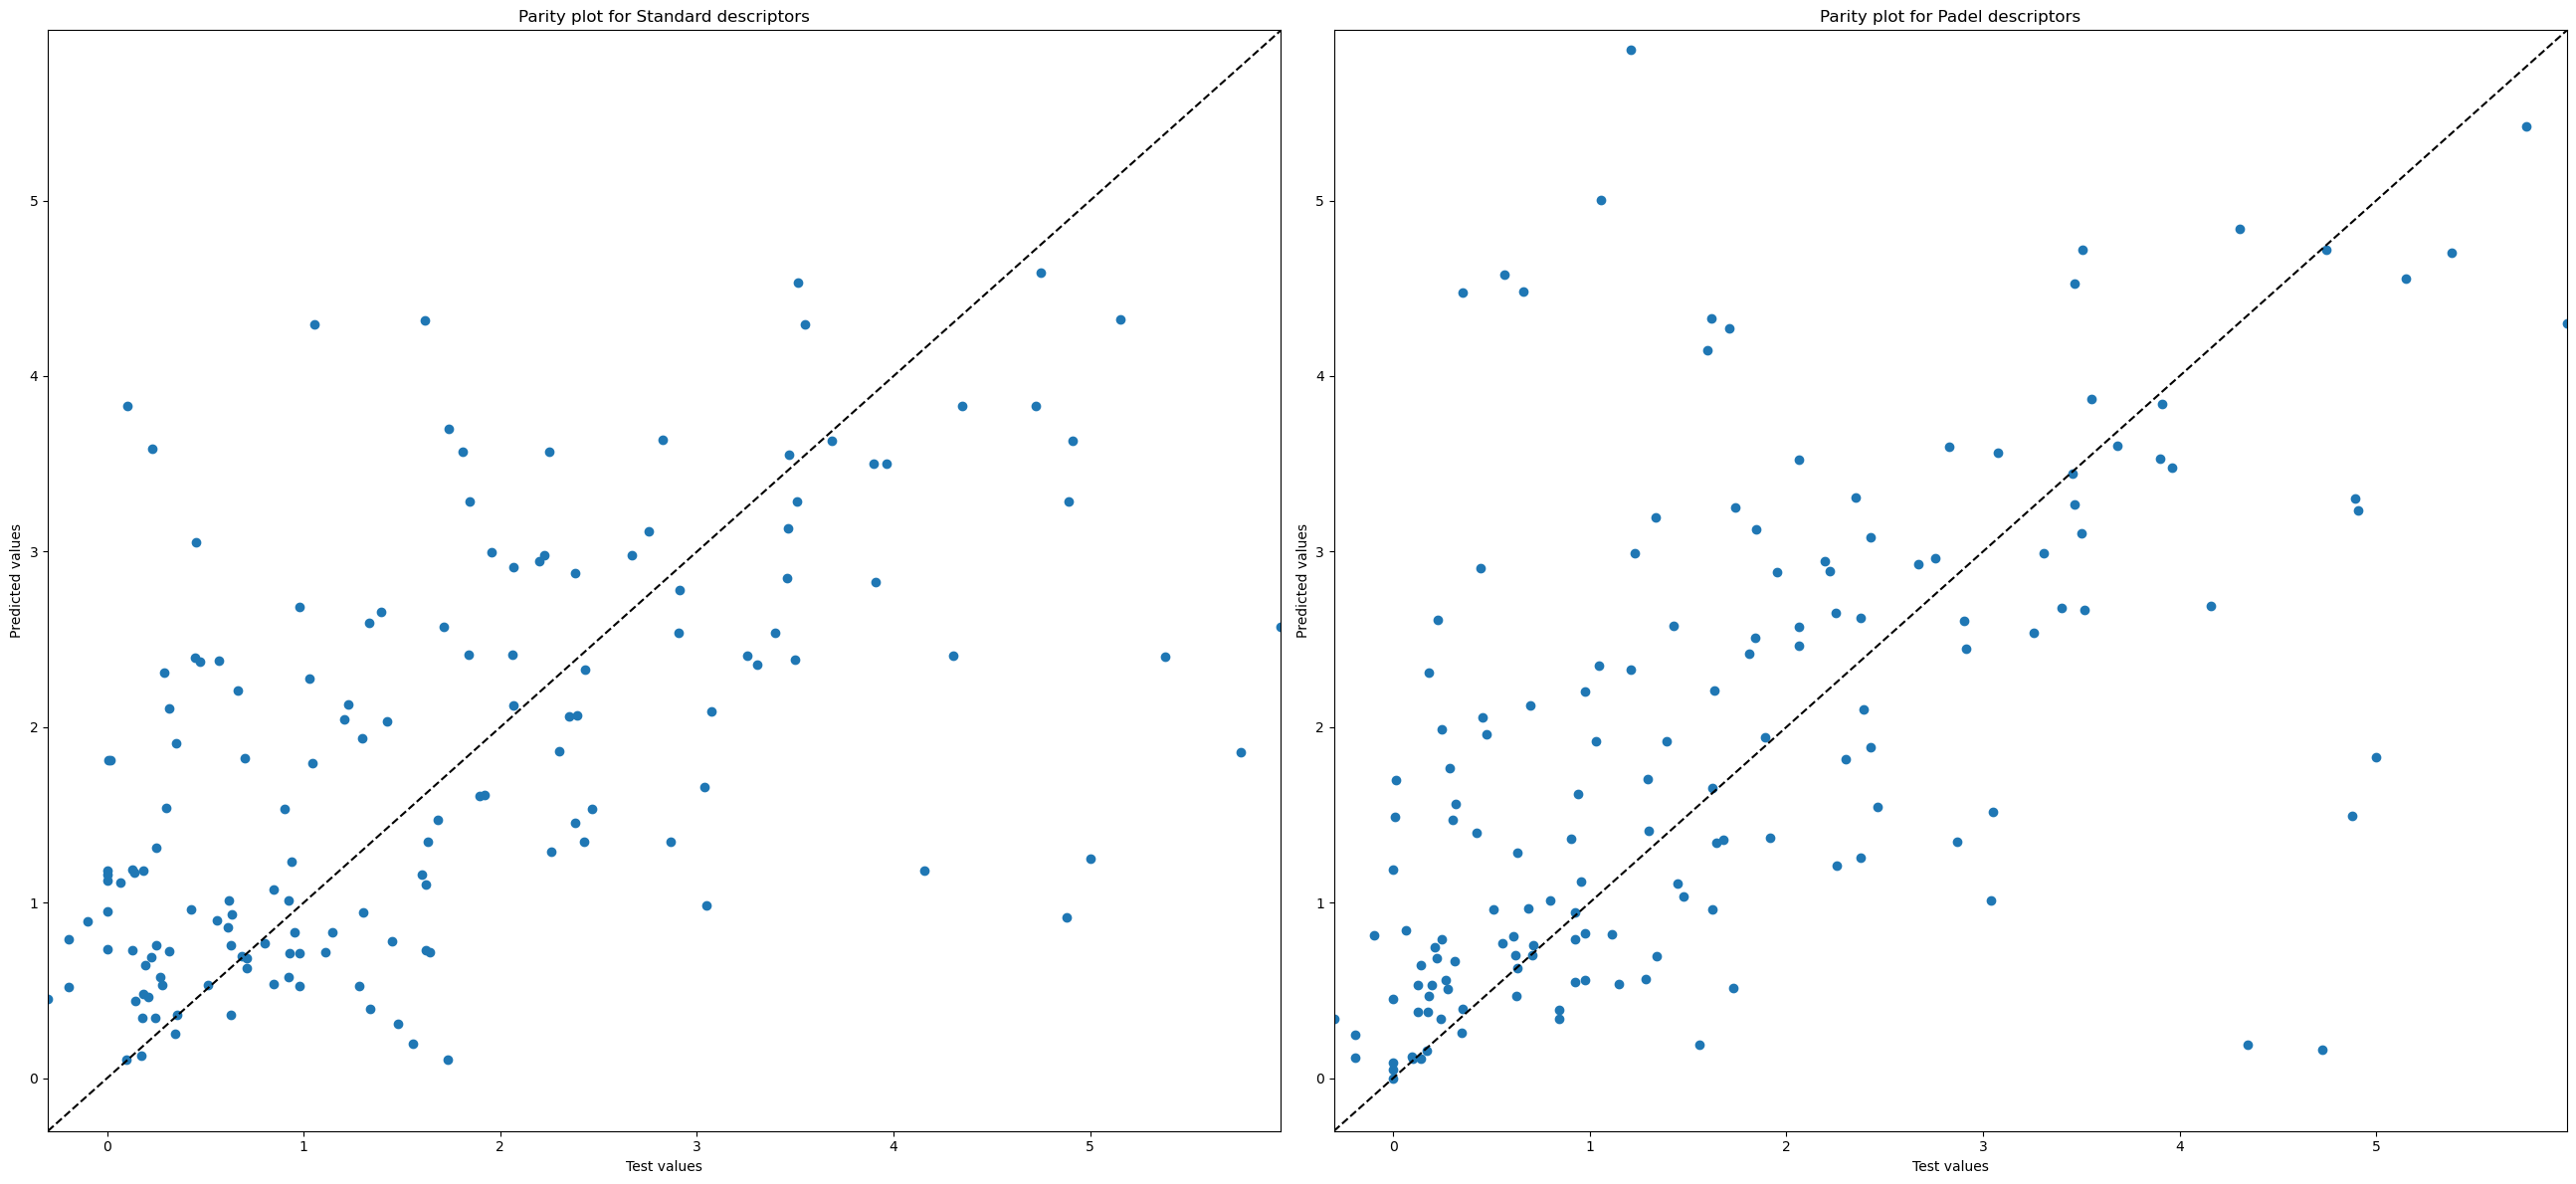

In [371]:
calculate_to_score(pipe, estimator_name='KMeans', param_grid=space, 
                   descriptors_dict=descriptors_dict_pca, target=target, type = 'PCA')

Let's save results into pickle file and show the final scores model in readable format

In [372]:
pd.DataFrame(scores)

,Descriptors,Estimator,Full or PCA,RMSE_CV,Stddev_RMSE_CV,R2_CV,MAE_CV,RMSE_test,MAE_test,R2_test
0,Standard,Lasso regression,Full,1.504065,0.141487,0.219161,1.198186,1.483558,1.221858,-0.002496
1,Padel,Lasso regression,Full,1.494180,0.146362,0.229555,1.173825,1.271478,1.015393,0.263638
2,Standard,Lasso Regression,PCA,1.509100,0.146381,0.214068,1.201350,1.374908,1.125094,0.138965
3,Padel,Lasso Regression,PCA,1.481881,0.145458,0.242119,1.168208,1.320604,1.057723,0.205637
4,Standard,Random Forest,Full,1.173893,0.143650,0.507512,0.868480,1.239169,0.951892,0.300585
5,Padel,Random Forest,Full,1.053655,0.164394,0.599480,0.741928,1.080481,0.772953,0.468250
6,Standard,Random Forest,PCA,1.165982,0.160566,0.514577,0.863104,1.268733,1.029437,0.266814
7,Padel,Random Forest,PCA,1.104417,0.161661,0.561278,0.803841,1.206337,0.882380,0.337156
8,Standard,SVC,Full,1.524704,0.160628,0.196800,1.064828,1.271784,0.913927,0.263283
9,Padel,SVC,Full,1.447477,0.280471,0.250030,0.957283,1.483737,1.032201,-0.002737


In [218]:
scores_df = pd.DataFrame(scores)

In [236]:
scores_df['R2_CV'] = scores_df['R2_CV'].apply(np.mean)

In [248]:
scores = scores_df.to_dict()

In [250]:
with open('score_regression_random.pickle', 'wb') as output:
    pickle.dump(scores, output)